# **Project Title: Predicting divorce**
by Kabir, Rodrigue and Sertac

**Research main objective**

This project aims to develop and validate predictive models of divorce using multidimensional determinants (demographic, socioeconomic, relational, and psychological characteristics), and to identify the key factors that most strongly contribute to marital dissolution. 

Specifically, it seeks at 

-	Training and comparing multiple supervised learning models predicting divorce
-	Identifiy the most important predictors of divorce


**Research questions**

- Which supervised machine-learning model and deep learning models offers the most reliable and robust prediction of divorce?
-	Which factors contribute most to predicting divorce ?


**Methods**
-	Exploration of the dataset 
-	Preparation of the dataset
-	Training and comparison of supervised learning models
-	Identification of  the most important predictors of divorce


In [1]:
#Load libraries that will be used throughout the project (will be continuouysly updated)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    roc_curve,
    auc
)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetClassifier
import copy



In [2]:
# Load the dataset
df = pd.read_csv('divorce_df.csv')
df.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,Yes,5.536016,3,...,No,No,No,8.428183,5,Love,Yes,No,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,Yes,5.810172,3,...,No,Yes,No,5.297221,1,Love,Yes,No,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,No,6.088146,3,...,No,No,No,5.887066,1,Arranged,Yes,No,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,Yes,6.212046,3,...,No,No,No,5.263555,5,Love,Yes,No,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,Yes,4.826262,1,...,No,No,Yes,5.771259,4,Love,Yes,No,10.000000,1


In [3]:
# Make a copy of the original dataset
df1 = df.copy()
df1.head()

,age_at_marriage,marriage_duration_years,num_children,education_level,employment_status,combined_income,religious_compatibility,cultural_background_match,communication_score,conflict_frequency,...,mental_health_issues,infidelity_occurred,counseling_attended,social_support,shared_hobbies_count,marriage_type,pre_marital_cohabitation,domestic_violence_history,trust_score,divorced
0,30,1,1,Bachelor,Full-time,64001,Different Religion,Yes,5.536016,3,...,No,No,No,8.428183,5,Love,Yes,No,6.262411,1
1,27,2,2,Master,Full-time,86221,Same Religion,Yes,5.810172,3,...,No,Yes,No,5.297221,1,Love,Yes,No,6.769384,1
2,31,6,0,High School,Part-time,69441,Same Religion,No,6.088146,3,...,No,No,No,5.887066,1,Arranged,Yes,No,5.532866,1
3,35,3,2,Bachelor,Full-time,69513,Not Religious,Yes,6.212046,3,...,No,No,No,5.263555,5,Love,Yes,No,3.491264,0
4,26,2,2,No Formal Education,Full-time,63986,Different Religion,Yes,4.826262,1,...,No,No,Yes,5.771259,4,Love,Yes,No,10.000000,1


In [4]:
#Show the list of columns in the dataset
df1.columns

Index(['age_at_marriage', 'marriage_duration_years', 'num_children',
       'education_level', 'employment_status', 'combined_income',
       'religious_compatibility', 'cultural_background_match',
       'communication_score', 'conflict_frequency',
       'conflict_resolution_style', 'financial_stress_level',
       'mental_health_issues', 'infidelity_occurred', 'counseling_attended',
       'social_support', 'shared_hobbies_count', 'marriage_type',
       'pre_marital_cohabitation', 'domestic_violence_history', 'trust_score',
       'divorced'],
      dtype='object')

In [5]:
# Produce summary statistics of the dataset
df1.drop('divorced', axis=1).describe()

,age_at_marriage,marriage_duration_years,num_children,combined_income,communication_score,conflict_frequency,financial_stress_level,social_support,shared_hobbies_count,trust_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,27.583600,9.171000,1.552800,60220.078400,6.040507,2.008000,5.071450,5.966853,2.972600,6.030525
std,4.855978,8.848266,1.247527,19662.080982,1.963349,1.412351,2.326322,1.965504,1.711735,1.932922
min,18.000000,1.000000,0.000000,10000.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000
25%,24.000000,2.000000,1.000000,46666.000000,4.661929,1.000000,3.365562,4.597007,2.000000,4.702663
50%,28.000000,6.000000,1.000000,60196.000000,6.058246,2.000000,5.062464,6.010716,3.000000,6.034343
75%,31.000000,13.000000,2.000000,73666.500000,7.426862,3.000000,6.717954,7.328916,4.000000,7.372830
max,45.000000,40.000000,6.000000,126909.000000,10.000000,9.000000,10.000000,10.000000,10.000000,10.000000


In [6]:
# Generating consolidated frequency table for binary variables
binary_columns = ['cultural_background_match','mental_health_issues','infidelity_occurred','counseling_attended','pre_marital_cohabitation','domestic_violence_history','divorced']

consolidated_table = pd.DataFrame(columns=[0, 1])
for col in binary_columns:
    vc = df1[col].value_counts()
    for cat, count in vc.items():
        if cat == 'Yes' or cat == 1:
            consolidated_table.loc[col, 1] = count
        elif cat == 'No' or cat == 0:
            consolidated_table.loc[col, 0] = count

consolidated_table = consolidated_table.fillna(0).astype(int)
consolidated_table = consolidated_table.rename(columns={0: 'No', 1: 'Yes'})

print("Consolidated Frequency Table:")
print(consolidated_table)

Consolidated Frequency Table:
                             No   Yes
cultural_background_match  1223  3777
mental_health_issues       3981  1019
infidelity_occurred        4255   745
counseling_attended        3798  1202
pre_marital_cohabitation   2039  2961
domestic_violence_history  4748   252
divorced                   3009  1991


C:\Users\kabir\AppData\Local\Temp\ipykernel_29920\553892133.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  consolidated_table = consolidated_table.fillna(0).astype(int)


In [7]:
#Generating frequency tables for multi categorical variables
multi_categorical_columns = ['education_level', 'employment_status', 'marriage_type', 'religious_compatibility', 'conflict_resolution_style']
for col in multi_categorical_columns:
    print(f"Frequency Table for {col}:")
    print(df1[col].value_counts())
    print("\n")

Frequency Table for education_level:
education_level
Bachelor               2069
High School            1513
Master                  963
No Formal Education     231
PhD                     224
Name: count, dtype: int64


Frequency Table for employment_status:
employment_status
Full-time     2487
Part-time     1028
Homemaker      748
Unemployed     737
Name: count, dtype: int64


Frequency Table for marriage_type:
marriage_type
Love        3513
Arranged    1231
Other        256
Name: count, dtype: int64


Frequency Table for religious_compatibility:
religious_compatibility
Same Religion         3040
Not Religious         1003
Different Religion     957
Name: count, dtype: int64


Frequency Table for conflict_resolution_style:
conflict_resolution_style
Collaborative    2028
Avoidant         1250
Aggressive        994
Passive           728
Name: count, dtype: int64




In [8]:
# Check for missing values
df1.isnull().sum()

age_at_marriage              0
marriage_duration_years      0
num_children                 0
education_level              0
employment_status            0
combined_income              0
religious_compatibility      0
cultural_background_match    0
communication_score          0
conflict_frequency           0
conflict_resolution_style    0
financial_stress_level       0
mental_health_issues         0
infidelity_occurred          0
counseling_attended          0
social_support               0
shared_hobbies_count         0
marriage_type                0
pre_marital_cohabitation     0
domestic_violence_history    0
trust_score                  0
divorced                     0
dtype: int64

**Pre-processing and preparation of the dataset for machine learning**

In [62]:
# Define features and target variable
X = df1[['age_at_marriage', 'marriage_duration_years', 'num_children','education_level','employment_status','combined_income','religious_compatibility','cultural_background_match','communication_score','conflict_frequency','conflict_resolution_style','financial_stress_level','mental_health_issues','infidelity_occurred','counseling_attended','social_support','shared_hobbies_count','marriage_type','pre_marital_cohabitation','domestic_violence_history','trust_score']]
y = df1['divorced']

# Split the dataset into training and testing sets with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"--- Dataset Split Results ---")
print(f"Total samples: {len(df1)}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")
print(f"y_test distribution:\n{y_test.value_counts(normalize=True)}")
print(f"-----------------------------")

--- Dataset Split Results ---
Total samples: 5000
X_train shape: (4000, 21)
X_test shape: (1000, 21)
y_train distribution:
divorced
0    0.60175
1    0.39825
Name: proportion, dtype: float64
y_test distribution:
divorced
0    0.602
1    0.398
Name: proportion, dtype: float64
-----------------------------


In [63]:
# 2. Preprocessing for numerical and categorical features
numerical_features = ['age_at_marriage','marriage_duration_years','num_children','combined_income','communication_score','conflict_frequency','financial_stress_level','social_support','shared_hobbies_count','trust_score']
categorical_features = ['education_level','employment_status','religious_compatibility','cultural_background_match','conflict_resolution_style','infidelity_occurred','counseling_attended','marriage_type','pre_marital_cohabitation','domestic_violence_history','mental_health_issues']


numerical_transformer = StandardScaler() # Scale continuous features
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False) # Convert categorical features to numerical

# 3. Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough'
)

**Machine learning models**

Model1: Logistic Regression


--- Training Model (Logistic Regression Classifier) ---
Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27             

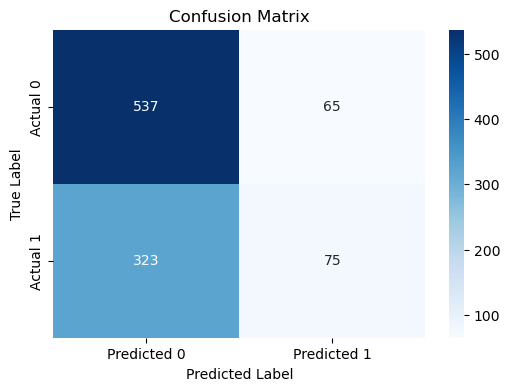


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.89      0.73       602
           1       0.54      0.19      0.28       398

    accuracy                           0.61      1000
   macro avg       0.58      0.54      0.51      1000
weighted avg       0.59      0.61      0.55      1000



In [64]:
# Define divorce_model1 (Logistic Regression)
divorce_model1 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', LogisticRegression(random_state=1))])
# Train the model
divorce_model1.fit(X_train, y_train) 

# Predict on the test set
y_pred = divorce_model1.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Logistic Regression Classifier) ---")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model1.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))



C:\Users\kabir\AppData\Local\Temp\ipykernel_29920\2019471720.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


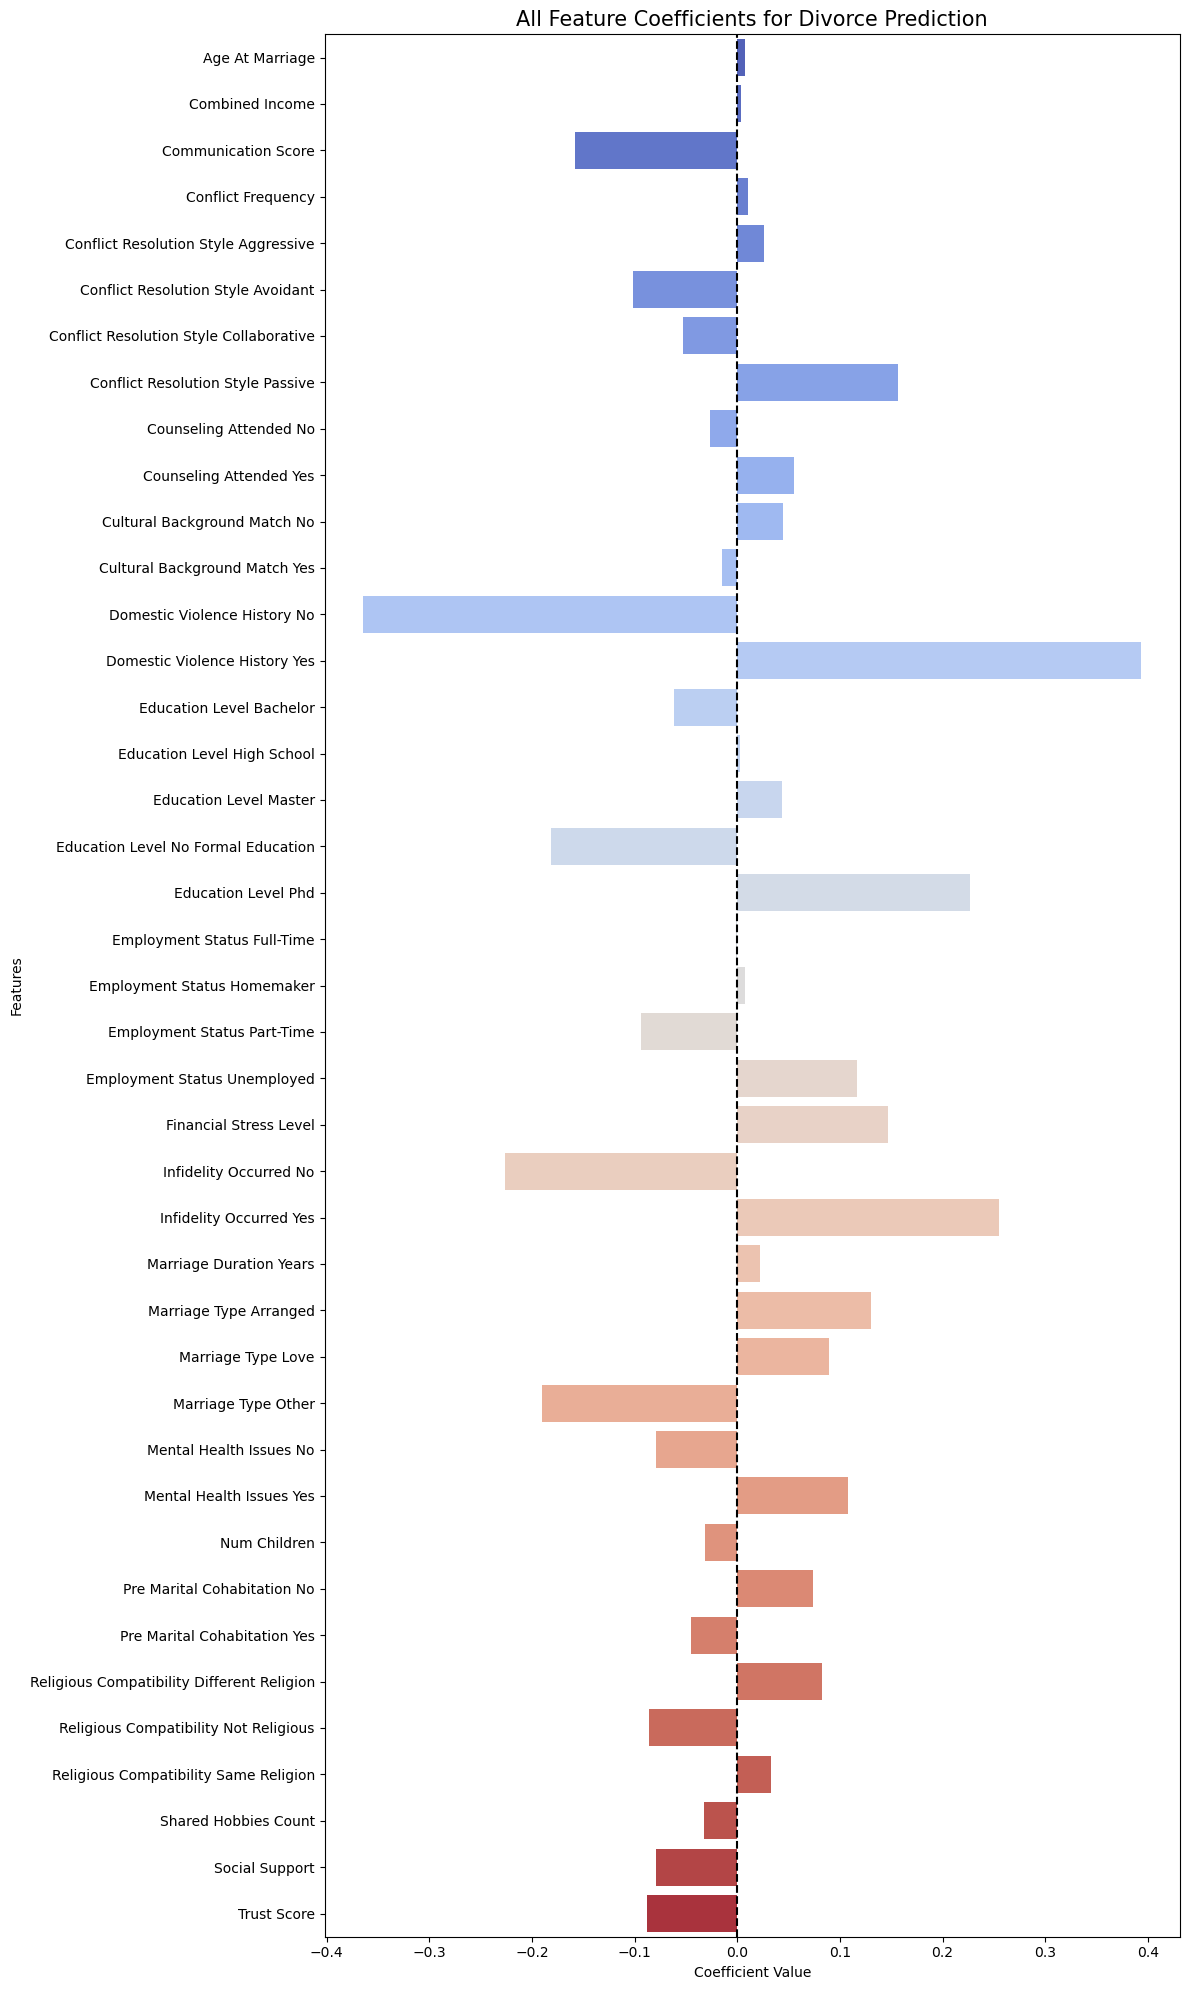

In [65]:
# Get model
logistic_model = divorce_model1.named_steps['classifier']

# Feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model1.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)

# Coefficients
coefficients = logistic_model.coef_[0]

# Build dataframe
feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Make labels readable
plot_features = feature_importance.copy()
plot_features['Feature'] = (
    plot_features['Feature']
    .str.replace('_',' ')
    .str.title()
)

# Sort alphabetically
plot_features = plot_features.sort_values(by='Feature')

# Plot
plt.figure(figsize=(12,20))

sns.barplot(
    data=plot_features,
    x='Coefficient',
    y='Feature',
    palette='coolwarm'
)

plt.axvline(
    0,
    color='black',
    linestyle='--'
)

plt.title(
    'All Feature Coefficients for Divorce Prediction',
    fontsize=15
)

plt.xlabel(
    'Coefficient Value'
)

plt.ylabel(
    'Features'
)

plt.tight_layout()

plt.show()

Model2: Random Forest Classifier


--- Training Model (Random Forest Classifier) ---
Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                   

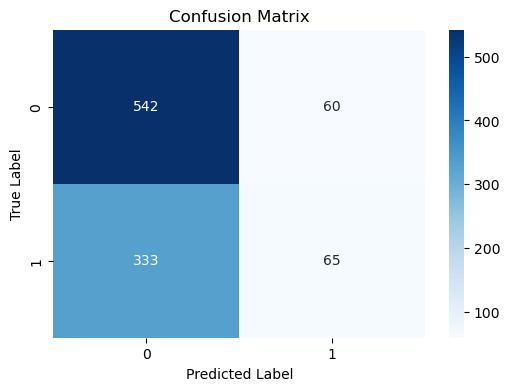


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.90      0.73       602
           1       0.52      0.16      0.25       398

    accuracy                           0.61      1000
   macro avg       0.57      0.53      0.49      1000
weighted avg       0.58      0.61      0.54      1000



In [66]:
# Define divorce_model2 (Random Forest Classifier)
divorce_model2 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', RandomForestClassifier(n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        random_state=42))])
# Train the model
divorce_model2.fit(X_train, y_train) 
# Predict on the test set
y_pred = divorce_model2.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (Random Forest Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model2.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['0', '1'], yticklabels=['0', '1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

C:\Users\kabir\AppData\Local\Temp\ipykernel_29920\2128857191.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


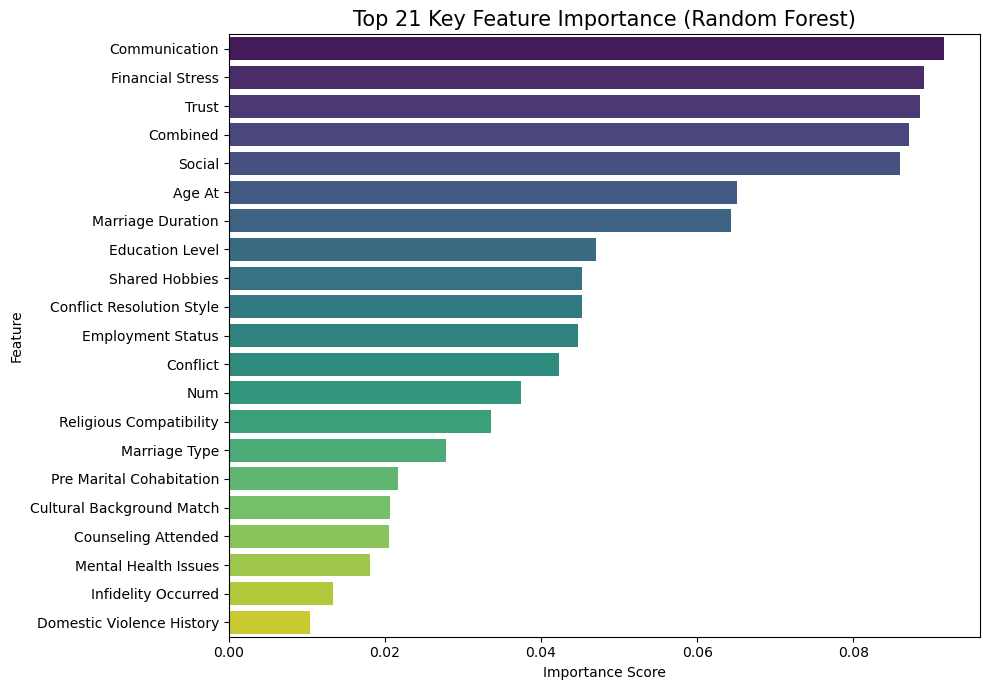

In [67]:
# Get trained Random Forest
rf_model = divorce_model2.named_steps['classifier']


# Get feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model2.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)


# Importance
importance = rf_model.feature_importances_


feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importance
})


# Clean names and combine all dummies for the same original feature
feature_importance['Feature'] = feature_importance['Feature'].apply(
    lambda x: x.rsplit('_', 1)[0].replace('_', ' ').title() if '_' in x else x.replace('_', ' ').title()
)


# Combine duplicated features by summing importance
feature_importance = (
    feature_importance
    .groupby('Feature', as_index=False)
    ['Importance']
    .sum()
)


# Sort by importance and select top 20
plot_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(21)


# Plot
plt.figure(figsize=(10,7))

sns.barplot(
    data=plot_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 21 Key Feature Importance (Random Forest)',
    fontsize=15
)

plt.xlabel(
    'Importance Score'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()

Model3: XGBoost Classifier


--- Training Model (XGBoost Classifier) ---
Making predictions for the following 5 couples:
   age_at_marriage  marriage_duration_years  num_children      education_level employment_status  combined_income religious_compatibility cultural_background_match  communication_score  conflict_frequency conflict_resolution_style  financial_stress_level mental_health_issues infidelity_occurred counseling_attended  social_support  shared_hobbies_count marriage_type pre_marital_cohabitation domestic_violence_history  trust_score
0               30                        1             1             Bachelor         Full-time            64001      Different Religion                       Yes             5.536016                   3             Collaborative                6.026355                   No                  No                  No        8.428183                     5          Love                      Yes                        No     6.262411
1               27                        2

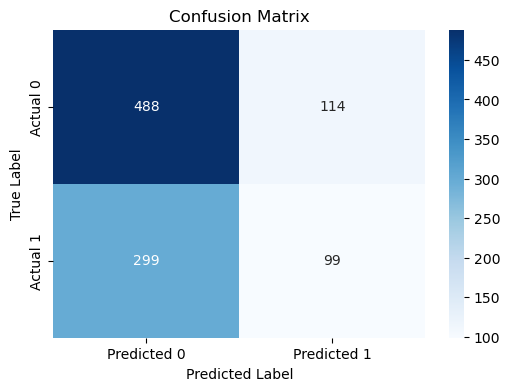


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.81      0.70       602
           1       0.46      0.25      0.32       398

    accuracy                           0.59      1000
   macro avg       0.54      0.53      0.51      1000
weighted avg       0.56      0.59      0.55      1000



In [68]:
# Define divorce_model3 (Xgboost Classifier)
divorce_model3 = Pipeline(steps=[('preprocessor', preprocessor),('classifier', XGBClassifier(n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'))])
# Train the model
divorce_model3.fit(X_train, y_train) 
# Predict on the test set
y_pred = divorce_model3.predict(X_test) 
# Evaluation of the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print("\n--- Training Model (XGBoost Classifier) ---")

print("Making predictions for the following 5 couples:")
print(X.head())
print("The predictions are")
print(divorce_model3.predict(X.head()))

print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])    
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


print("\nClassification Report:")
print(classification_report(y_test, y_pred))

C:\Users\serta\AppData\Local\Temp\ipykernel_33480\1729672684.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


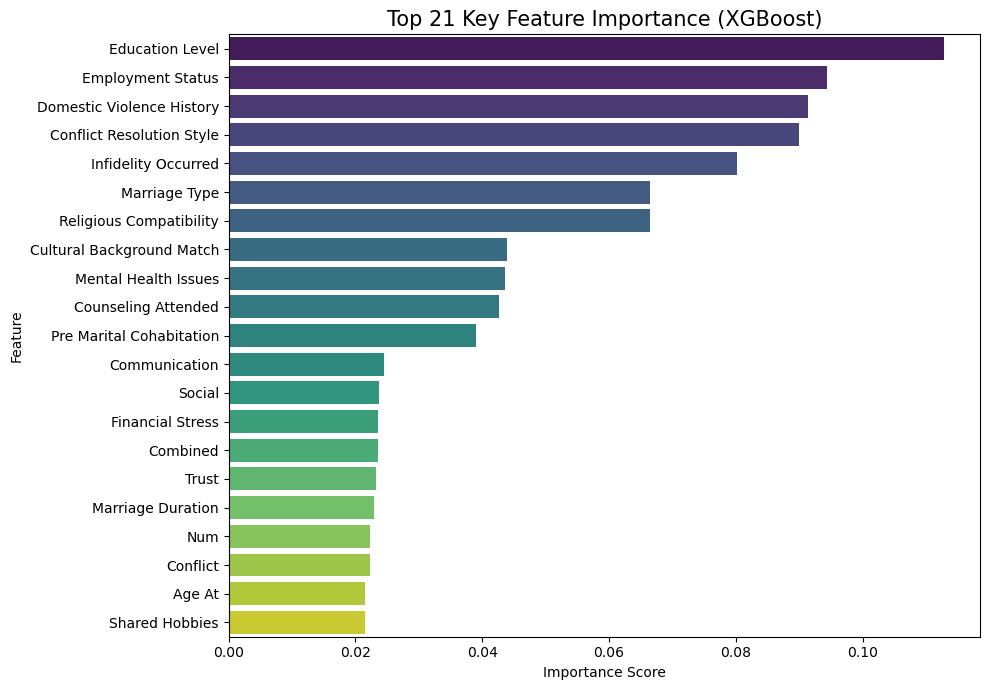

In [ ]:
# Get trained XGBoost
xgb_model = divorce_model3.named_steps['classifier']


# Get feature names
feature_names_num = numerical_features

feature_names_cat = divorce_model3.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_features)

all_feature_names = list(feature_names_num) + list(feature_names_cat)


# Importance
importance = xgb_model.feature_importances_


feature_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importance
})


# Clean names and combine all dummies for the same original feature
feature_importance['Feature'] = feature_importance['Feature'].apply(
    lambda x: x.rsplit('_', 1)[0].replace('_', ' ').title() if '_' in x else x.replace('_', ' ').title()
)


# Combine duplicated features by summing importance
feature_importance = (
    feature_importance
    .groupby('Feature', as_index=False)
    ['Importance']
    .sum()
)


# Sort by importance and select top 20
plot_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(21)


# Plot
plt.figure(figsize=(10,7))

sns.barplot(
    data=plot_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title(
    'Top 21 Key Feature Importance (XGBoost)',
    fontsize=15
)

plt.xlabel(
    'Importance Score'
)

plt.ylabel(
    'Feature'
)

plt.tight_layout()

plt.show()

## Deep Learning

Model1: Neural Network Deep Forward with 32 Neurons & 64 Neurons

In [12]:
import random

# set random seeds for pytorch, numpy, and paython's built-in random module for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [13]:
# Starting from the output of the preprocessing pipeline
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [14]:
# Split the training data into a smaller training set and a validation set
X_train_full, X_val, y_train_full, y_val = train_test_split(
    X_train_processed, y_train, test_size=0.2, random_state=42
)

In [15]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_full, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_full.values, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)



In [31]:
# Define the model_32 (A simple feedforward neural network)
#input_size = X_train_tensor.shape[1]

model_32 = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 1),
    #nn.Sigmoid()
)


In [32]:
# Define the model_32a (A simple feedforward neural network)
#input_size = X_train_tensor.shape[1]

model_32a = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 32),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    nn.Linear(16, 1),
    #nn.Sigmoid()
)


In [33]:
# Define the model_64 (An improved version of Model_32)
model_64 = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    
    nn.Linear(32, 1),

)

In [34]:
#Defining model 64a (An improved version of Model_64)
model_64a = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 64),
    nn.ReLU(),
    

    nn.Linear(64, 32),
    nn.ReLU(),
    
    
    nn.Linear(32, 16),
    nn.ReLU(),
    
    
    nn.Linear(16, 1),

)


In [35]:
# Loss and Optimizer (both for model_32 and model_64)
pos_weight = torch.tensor([602/398])  # Calculate the ratio of negative to positive samples
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight) # Binary Cross Entropy with Logits (more stable)

optimizer_32 = optim.Adam(model_32.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_32a = optim.Adam(model_32a.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_64 = optim.Adam(model_64.parameters(), lr=0.001, weight_decay=1e-4)
optimizer_64a = optim.Adam(model_64a.parameters(), lr=0.001, weight_decay=1e-4)

In [36]:
# Training Loop with Early Stopping

def train_model(model, optimizer, epochs = 100, patience = 15):
    
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    best_model_state = None
    counter = 0
    

    for epoch in range(epochs):

        # TRAIN
        model.train()
        optimizer.zero_grad()

        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)

        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        # VALIDATION
        model.eval()
        with torch.no_grad():
             val_outputs = model(X_val_tensor)   # or X_val_tensor if you have a validation split
             val_loss = criterion(val_outputs, y_val_tensor)
    
        val_losses.append(val_loss.item())

        # EARLY STOPPING
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_model_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break


        if (epoch+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

     # restore best model
    model.load_state_dict(best_model_state)

    return train_losses, val_losses, model

In [37]:
# train the models
train_32, val_32, model_32 = train_model(model_32, optimizer_32)
train_32a, val_32a, model_32a = train_model(model_32a, optimizer_32a)
train_64, val_64, model_64 = train_model(model_64, optimizer_64)
train_64a, val_64a, model_64a = train_model(model_64a, optimizer_64a)

Epoch [10/100], Train Loss: 0.8321, Val Loss: 0.8310
Epoch [20/100], Train Loss: 0.8287, Val Loss: 0.8286
Epoch [30/100], Train Loss: 0.8245, Val Loss: 0.8264
Epoch [40/100], Train Loss: 0.8195, Val Loss: 0.8247
Epoch [50/100], Train Loss: 0.8136, Val Loss: 0.8241
Epoch [60/100], Train Loss: 0.8078, Val Loss: 0.8241
Epoch [70/100], Train Loss: 0.8019, Val Loss: 0.8251
Early stopping at epoch 72
Epoch [10/100], Train Loss: 0.8346, Val Loss: 0.8332
Epoch [20/100], Train Loss: 0.8331, Val Loss: 0.8317
Epoch [30/100], Train Loss: 0.8333, Val Loss: 0.8306
Epoch [40/100], Train Loss: 0.8287, Val Loss: 0.8295
Epoch [50/100], Train Loss: 0.8265, Val Loss: 0.8280
Epoch [60/100], Train Loss: 0.8224, Val Loss: 0.8262
Epoch [70/100], Train Loss: 0.8210, Val Loss: 0.8245
Epoch [80/100], Train Loss: 0.8178, Val Loss: 0.8236
Epoch [90/100], Train Loss: 0.8114, Val Loss: 0.8230
Epoch [100/100], Train Loss: 0.8103, Val Loss: 0.8230
Epoch [10/100], Train Loss: 0.8347, Val Loss: 0.8313
Epoch [20/100], Tr

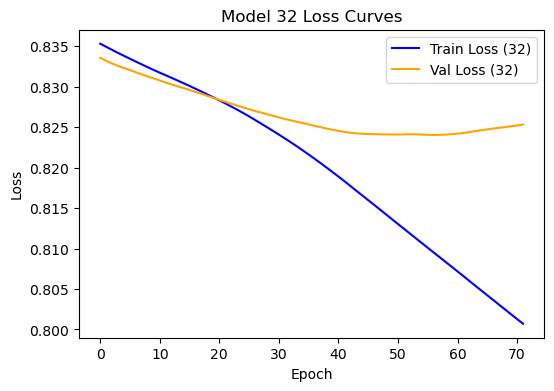

In [38]:
# Loss Curves for model_32
plt.figure(figsize=(6, 4))
plt.plot(train_32, label='Train Loss (32)', color='blue')
plt.plot(val_32, label='Val Loss (32)', color='orange')
plt.title('Model 32 Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

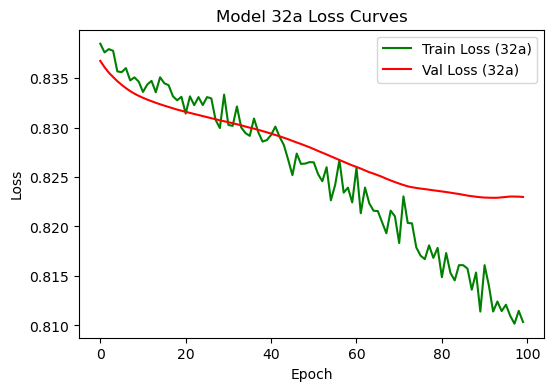

In [39]:
#Loss Curves for model_32a
plt.figure(figsize=(6, 4))
plt.plot(train_32a, label='Train Loss (32a)', color='green')
plt.plot(val_32a, label='Val Loss (32a)', color='red')
plt.title('Model 32a Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

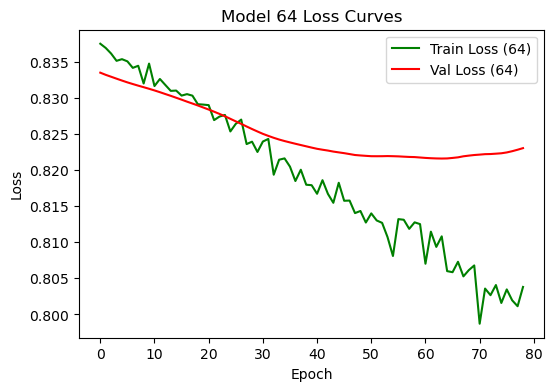

In [40]:
# Loss Curves for model_64
plt.figure(figsize=(6, 4))
plt.plot(train_64, label='Train Loss (64)', color='green')
plt.plot(val_64, label='Val Loss (64)', color='red')
plt.title('Model 64 Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

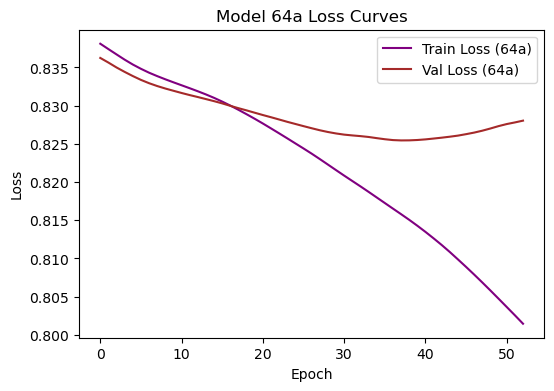

In [41]:
#Plotting the loss curves for model_64a
plt.figure(figsize=(6, 4))
plt.plot(train_64a, label='Train Loss (64a)', color='purple')
plt.plot(val_64a, label='Val Loss (64a)', color='brown')
plt.title('Model 64a Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [42]:
# Evaluate the model_32
model_32.eval()
with torch.no_grad():
    y_pred_prob = model_32(X_test_tensor)
    y_pred = (torch.sigmoid(y_pred_prob) > 0.5).float()


In [43]:
#Evaluate the model_32a
model_32a.eval()
with torch.no_grad():
    y_pred_prob_32a = model_32a(X_test_tensor)
    y_pred_32a = (torch.sigmoid(y_pred_prob_32a) > 0.5).float()

In [44]:
# Evaluate the model_64
model_64.eval()
with torch.no_grad():
    y_pred_prob_64 = model_64(X_test_tensor)
    y_pred_64 = (torch.sigmoid(y_pred_prob_64) > 0.5).float()

In [45]:
#Evaluate the model_64a
model_64a.eval()
with torch.no_grad():
    y_pred_prob_64a = model_64a(X_test_tensor)
    y_pred_64a = (torch.sigmoid(y_pred_prob_64a) > 0.5).float()

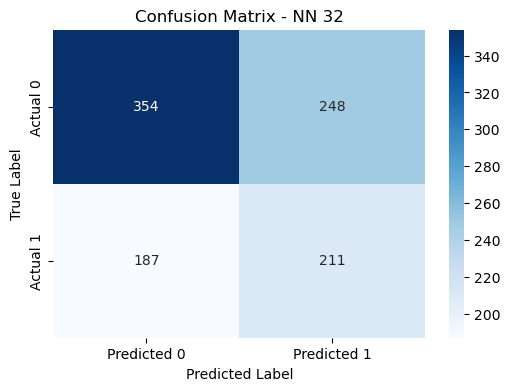


 Model 32 Classification Report:
              precision    recall  f1-score   support

         0.0       0.65      0.59      0.62       602
         1.0       0.46      0.53      0.49       398

    accuracy                           0.56      1000
   macro avg       0.56      0.56      0.56      1000
weighted avg       0.58      0.56      0.57      1000



In [46]:
# Display confusion matrix to analyze classification performance
conf_matrix_32 = confusion_matrix(y_test_tensor.numpy(), y_pred.numpy())

#print("\n--- Confusion Matrix ---")
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_32, annot=True, fmt='d', cmap='Blues',xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix - NN 32")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
print("\n Model 32 Classification Report:")
print(classification_report(y_test_tensor.numpy(), y_pred.numpy()))

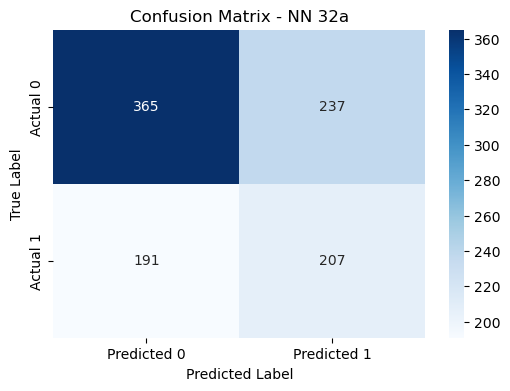


 Model 32a Classification Report:
              precision    recall  f1-score   support

         0.0       0.66      0.61      0.63       602
         1.0       0.47      0.52      0.49       398

    accuracy                           0.57      1000
   macro avg       0.56      0.56      0.56      1000
weighted avg       0.58      0.57      0.58      1000



In [47]:
#Confusion matrix for model_32a
conf_matrix_32a = confusion_matrix(y_test_tensor.numpy(), y_pred_32a.numpy())
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_32a, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title("Confusion Matrix - NN 32a")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()
print("\n Model 32a Classification Report:")
print(classification_report(y_test_tensor.numpy(), y_pred_32a.numpy()))


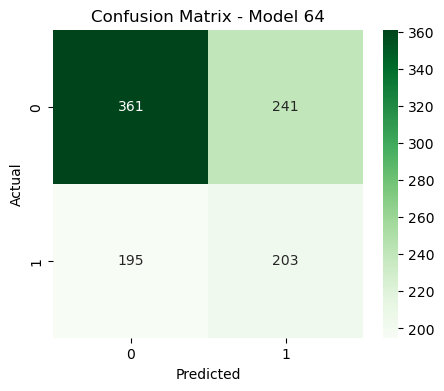

Model 64 Classification Report
              precision    recall  f1-score   support

         0.0       0.65      0.60      0.62       602
         1.0       0.46      0.51      0.48       398

    accuracy                           0.56      1000
   macro avg       0.55      0.55      0.55      1000
weighted avg       0.57      0.56      0.57      1000



In [48]:
conf_matrix_64 = confusion_matrix(y_test_tensor.numpy(), y_pred_64.numpy())

plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix_64, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Model 64")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Model 64 Classification Report")
print(classification_report(y_test_tensor.numpy(), y_pred_64.numpy()))

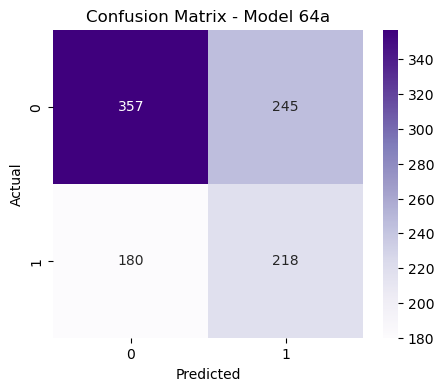

Model 64a Classification Report
              precision    recall  f1-score   support

         0.0       0.66      0.59      0.63       602
         1.0       0.47      0.55      0.51       398

    accuracy                           0.57      1000
   macro avg       0.57      0.57      0.57      1000
weighted avg       0.59      0.58      0.58      1000



In [50]:
#Confusion matrix for model_64a
conf_matrix_64a = confusion_matrix(y_test_tensor.numpy(), y_pred_64a.numpy())
plt.figure(figsize=(5,4))
sns.heatmap(conf_matrix_64a, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Model 64a")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("Model 64a Classification Report")
print(classification_report(y_test_tensor.numpy(), y_pred_64a.numpy()))


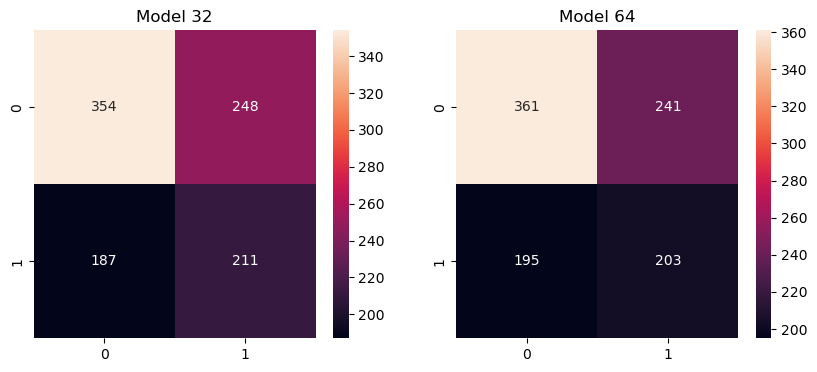

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(conf_matrix_32, annot=True, fmt='d', ax=axes[0])
axes[0].set_title("Model 32")

sns.heatmap(conf_matrix_64, annot=True, fmt='d', ax=axes[1])
axes[1].set_title("Model 64")

plt.show()

Tabnet

In [52]:
X_train_tabnet = X_train_processed.astype("float32")
X_test_tabnet = X_test_processed.astype("float32")

y_train_tabnet = y_train.to_numpy().ravel()
y_test_tabnet = y_test.to_numpy().ravel()

In [53]:
X_train_tabnet, X_val_tabnet, y_train_tabnet, y_val_tabnet = train_test_split(
    X_train_tabnet,
    y_train_tabnet,
    test_size=0.2,
    random_state=42
)

In [54]:
# Define TabNet Classifier
tabnet = TabNetClassifier(
    n_d=16, # Dimension of the decision prediction layer
    n_a=16, # Dimension of the attention embedding for each mask
    n_steps=5,   # 7 biraz agresif, genelde 3-5 daha stabil
    gamma=1.5, # Relaxation parameter for the sparsemax
    lambda_sparse=1e-4, # Sparsity regularization strength
    verbose=10
)

tabnet.fit(
    X_train_tabnet, y_train_tabnet,
    eval_set=[(X_val_tabnet, y_val_tabnet)],
    eval_metric=['logloss', 'auc'],
    max_epochs=100,
    patience=10,
    batch_size=256,
    virtual_batch_size=128
)


c:\Users\kabir\miniforge3\envs\DSPy2025\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.98139 | val_0_logloss: 0.68338 | val_0_auc: 0.53208 |  0:00:01s
epoch 10 | loss: 0.67405 | val_0_logloss: 0.67369 | val_0_auc: 0.50261 |  0:00:17s

Early stopping occurred at epoch 13 with best_epoch = 3 and best_val_0_auc = 0.53763


c:\Users\kabir\miniforge3\envs\DSPy2025\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [55]:
y_probab = tabnet.predict_proba(X_test_tabnet)[:, 1]
y_pred = (y_probab >= 0.5).astype(int)

In [56]:
y_pred_tabnet = tabnet.predict(X_test_tabnet)

In [57]:
tabnet.history['loss']
tabnet.history['val_0_auc']

[0.5320764855442845,
 0.4945184923068858,
 0.4893056538491783,
 0.5376267987732956,
 0.48397158659012873,
 0.5179910094099762,
 0.5039415742706613,
 0.5178042515268276,
 0.519511284107887,
 0.517797698618647,
 0.5026146103640795,
 0.49664163455741656,
 0.5207039133967655,
 0.5328530051636916]

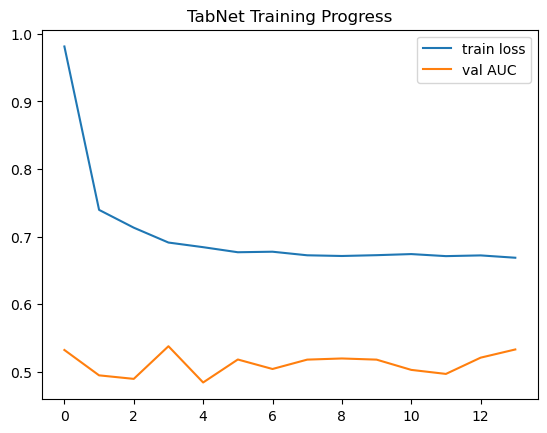

In [58]:
plt.plot(tabnet.history['loss'], label='train loss')
plt.plot(tabnet.history['val_0_auc'], label='val AUC')

plt.legend()
plt.title("TabNet Training Progress")
plt.show()

In [59]:
y_pred = tabnet.predict(X_test_tabnet)

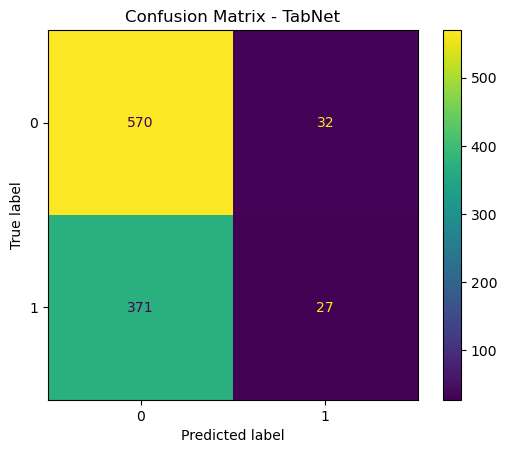

Classification Report - TabNet
              precision    recall  f1-score   support

           0       0.61      0.95      0.74       602
           1       0.46      0.07      0.12       398

    accuracy                           0.60      1000
   macro avg       0.53      0.51      0.43      1000
weighted avg       0.55      0.60      0.49      1000



In [60]:
# Evaluate the model
cm = confusion_matrix(y_test_tabnet, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - TabNet")
plt.show()


print("Classification Report - TabNet")
print(classification_report(y_test_tabnet, y_pred))

ROC-AUC Curve(Model Performance)

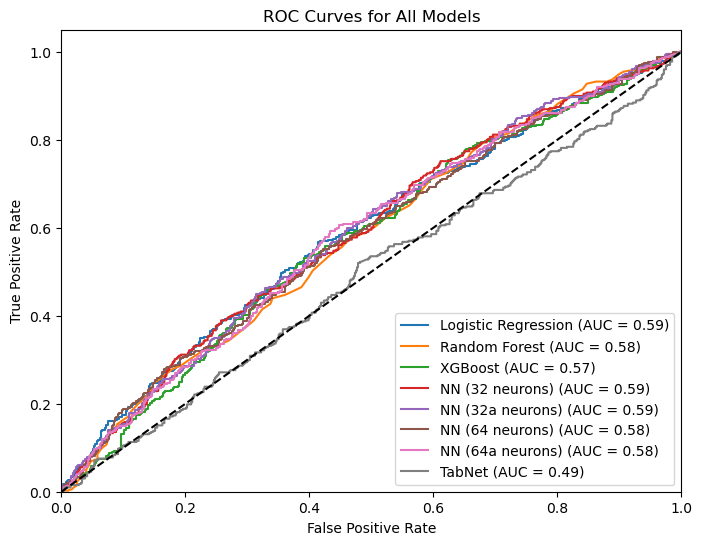


--- Classification Report Overview ---
                 Model  Accuracy  Precision  Recall  F1-Score     AUC
0  Logistic Regression     0.612     0.5357  0.1884    0.2788  0.5873
1        Random Forest     0.607     0.5200  0.1633    0.2486  0.5769
2              XGBoost     0.587     0.4648  0.2487    0.3241  0.5746
3      NN (32 neurons)     0.565     0.4597  0.5302    0.4924  0.5869
4     NN (32a neurons)     0.572     0.4662  0.5201    0.4917  0.5869
5      NN (64 neurons)     0.564     0.4572  0.5101    0.4822  0.5781
6     NN (64a neurons)     0.575     0.4708  0.5477    0.5064  0.5781
7               TabNet     0.597     0.4576  0.0678    0.1182  0.4930


In [71]:
# Pipelines
logistic_pipeline = divorce_model1
random_forest_pipeline = divorce_model2
xgb_pipeline = divorce_model3

plt.figure(figsize=(8, 6))

# Logistic Regression
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.2f})')

# Random Forest
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})')

# XGBoost
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.2f})')


# Neural Network (32)
model_32.eval()
with torch.no_grad():
    y_prob_nn_32 = torch.sigmoid(model_32(X_test_tensor)).numpy().ravel()

fpr_nn_32, tpr_nn_32, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_32)
auc_nn_32 = auc(fpr_nn_32, tpr_nn_32)
plt.plot(fpr_nn_32, tpr_nn_32, label=f'NN (32 neurons) (AUC = {auc_nn_32:.2f})')


#Neural Network (32a)
model_32a.eval()
with torch.no_grad():
    y_prob_nn_32a = torch.sigmoid(model_32a(X_test_tensor)).numpy().ravel()
fpr_nn_32a, tpr_nn_32a, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_32a)
auc_nn_32a = auc(fpr_nn_32a, tpr_nn_32a)
plt.plot(fpr_nn_32a, tpr_nn_32a, label=f'NN (32a neurons) (AUC = {auc_nn_32a:.2f})')

# Neural Network (64)
model_64.eval()
with torch.no_grad():
    y_prob_nn_64 = torch.sigmoid(model_64(X_test_tensor)).numpy().ravel()

fpr_nn_64, tpr_nn_64, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_64)
auc_nn_64 = auc(fpr_nn_64, tpr_nn_64)
plt.plot(fpr_nn_64, tpr_nn_64, label=f'NN (64 neurons) (AUC = {auc_nn_64:.2f})')

#Neural Network (64a)
model_64a.eval()
with torch.no_grad():
    y_prob_nn_64a = torch.sigmoid(model_64a(X_test_tensor)).numpy().ravel()
fpr_nn_64a, tpr_nn_64a, _ = roc_curve(y_test_tensor.numpy(), y_prob_nn_64a)
auc_nn_64a = auc(fpr_nn_64a, tpr_nn_64a)
plt.plot(fpr_nn_64a, tpr_nn_64a, label=f'NN (64a neurons) (AUC = {auc_nn_64a:.2f})')


# TabNet
y_prob_tabnet = tabnet.predict_proba(X_test_tabnet)[:, 1]

fpr_tabnet, tpr_tabnet, _ = roc_curve(y_test_tabnet, y_prob_tabnet)
auc_tabnet = auc(fpr_tabnet, tpr_tabnet)

plt.plot(fpr_tabnet, tpr_tabnet, label=f'TabNet (AUC = {auc_tabnet:.2f})')

# ROC Plot Settings
plt.plot([0, 1], [0, 1], 'k--')  # random baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

# Predictions
models = {
    'Logistic Regression': logistic_pipeline.predict(X_test),
    'Random Forest': random_forest_pipeline.predict(X_test),
    'XGBoost': xgb_pipeline.predict(X_test),
    'NN (32 neurons)': (y_prob_nn_32 >= 0.5).astype(int),
    'NN (32a neurons)': (y_prob_nn_32a >= 0.5).astype(int),
    'NN (64 neurons)': (y_prob_nn_64 >= 0.5).astype(int),
    'NN (64a neurons)': (y_prob_nn_64a >= 0.5).astype(int),
    'TabNet': y_pred_tabnet
}

y_test_np = y_test.values

summary = []

for name, y_pred in models.items():
    acc = accuracy_score(y_test_np, y_pred)
    prec = precision_score(y_test_np, y_pred)
    rec = recall_score(y_test_np, y_pred)
    f1 = f1_score(y_test_np, y_pred)

    if name == 'Logistic Regression':
        auc_val = auc_lr
    elif name == 'Random Forest':
        auc_val = auc_rf
    elif name == 'XGBoost':
        auc_val = auc_xgb
    
    elif name == 'TabNet':
        auc_val = auc_tabnet
        
    elif '32' in name:
        auc_val = auc_nn_32
    else:
        auc_val = auc_nn_64
        

    summary.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc_val
    })

summary_df = pd.DataFrame(summary)

print("\n--- Classification Report Overview ---")
print(summary_df.round(4))